Name: Bimal Rehman

Roll No: 25280081

# Task 1 — Forecasting Across Heterogeneous Sensors

AI651 / CS434 / EE5108 · implementation notebook

Use the Task 1 handout in `main.pdf` for concepts and response instructions. This notebook
contains the implementations, checks, and outputs for each part.

The simulated setting is a 20 Hz four-station production line. Products A, B, and C set global
nominal pace ranges of 14--18, 21--27, and 28--36 samples; each operating run has one actual pace from
its product range. Stations 1--3 are established and station 4 is held out.

Write every assessed response in your report. Each part has its own simple rhythm:
inspect its **Outputs**, then write its named **Response**.

| Part | You implement | Outputs | Response |
| --- | --- | --- | --- |
| 0. The World and Forecasting Setup | — | — | — |
| 1. Context-Dependent Forecasting | Raw Attention forecaster | 1.1–1.3 | 1A, 1B |
| 2. Separate Slow Structure from Repetition | `SeriesDecomposition.forward` | 2.1–2.3 | 2 |
| 3. Mix by Temporal Delay | `aggregate_delays` (`delay_scores` is supplied) | 3.1–3.2 | 3 |
| 4. Compare Designs and Deploy | — | 4.1–4.3 | 4 |

Short-horizon vibration forecasts provide the expected near-term baseline for condition monitoring.
Deviations from that expected behavior can indicate abnormal operation.

**Every implementation is checked where you write it.** Each implementation has a clear contract
and an immediate check; the numerical components also include small worked examples. Checks test
values, shapes, and gradients and name the likely cause when they fail. Nothing is left for a
training run to discover.


## 0. The World and Forecasting Setup

**Physical line:** Station 1 → Station 2 → Station 3 → Station 4. Each station has one vibration
accelerometer sampled at 20 Hz. Stations 1–3 are established; Station 4 is held out from fitting
but still supplies its own 96-sample context at inference time.

| Product | Actual pace in each operating run |
| --- | --- |
| A | 14–18 samples per cycle |
| B | 21–27 samples per cycle |
| C | 28–36 samples per cycle |

Each reading combines a slow drift, a repeating vibration, and small noise. A forecast receives
`L=96` readings from one station and predicts `H=48` future readings. Windows never cross a product
changeover. Train is samples 0–9600, validation is 9600–12480, and final test is 12480–15360.
Anchoring and scaling are supplied and use established-station training data only.

### Environment setup

Use Python 3.11 or later. From the unzipped assignment directory:

```bash
python -m venv .venv
# Linux/macOS:
source .venv/bin/activate
# Windows PowerShell:
# .venv\Scripts\Activate.ps1
python -m pip install -r requirements.txt
jupyter lab
```

For CPU-only PyTorch, install it from its CPU wheel index before installing the remaining
requirements:

```bash
python -m pip install torch --index-url https://download.pytorch.org/whl/cpu
python -m pip install -r requirements.txt
```

Keep `harness/` and `requirements.txt` beside this notebook.

#### Important: The notebook starts with PA1_PRESET=smoke only to make implementation and debugging fast. All results used in your report must come from a fresh PA1_PRESET=full run.

In [ ]:
import os
import zipfile
from pathlib import Path

# Colab: upload "Question 1.zip" to /content, then run all cells.
if Path("/content/Question 1.zip").exists() and not Path("/content/Question 1").exists():
    zipfile.ZipFile("/content/Question 1.zip").extractall("/content")
if Path("/content/Question 1/harness").is_dir():
    os.chdir("/content/Question 1")
os.environ.setdefault("PA1_PRESET", "full")  # submitted evidence must come from the full preset


'full'

In [ ]:
import math
import sys

for candidate in (Path("harness"), Path("PA 01/harness"), Path("../harness")):
    if candidate.is_dir():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise FileNotFoundError("Keep harness/ beside this notebook and start Jupyter there.")

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from IPython.display import display
import design_controls as design
import design_data as data
import design_diagnostics as figures
import design_models
import design_reporting as report

preset = os.environ.get("PA1_PRESET", "smoke")
seed = int(os.environ.get("PA1_SEED", "0"))
model_seed = int(os.environ.get("PA1_MODEL_SEED", str(seed)))
study = design.Study(preset, seed, model_seed=model_seed)
assert design.check_world(study.world)
print(f"preset={preset}; data seed={seed}; model seed={model_seed}; device={design.device}")
print(f"sampling rate={data.SAMPLING_RATE_HZ:g} Hz; products={', '.join(study.world.product_names)}")
print(f"product pace ranges={study.world.product_period_bands.tolist()} samples; "
      f"established stations={study.established.sum()}; held-out station=4")
print(f"eligible train/validation/test origins: "
      f"{len(study.region('train')['origins'])}/"
      f"{len(study.region('validation')['origins'])}/"
      f"{len(study.region('test')['origins'])}")


Four-station product-line world checks passed.
preset=full; data seed=0; model seed=0; device=cuda
sampling rate=20 Hz; products=Product A, Product B, Product C
product pace ranges=[[14.0, 18.0], [21.0, 27.0], [28.0, 36.0]] samples; established stations=3; held-out station=4
eligible train/validation/test origins: 650/105/105


In [ ]:
# Reuse the shipped full-preset checkpoints (checkpoints/) so the report numbers stay identical.
# The harness cache key hashes float arrays, so a different numpy build can miss the cache.
# On a miss this loads the shipped weights if their tensor shapes match; set PA1_RETRAIN=1 to refit.
import re

_harness_train = study.train

def _train_or_load_shipped(name="Raw Attention", cache=True, **kwargs):
    if os.environ.get("PA1_RETRAIN") == "1" or study.checkpoint_path(name, **kwargs).exists():
        return _harness_train(name, cache=cache, **kwargs)
    slug = re.sub(r"[^a-z0-9]+", "-", name.lower()).strip("-")
    for path in sorted(design.CHECKPOINTS.glob(f"{slug}-{preset}-data{seed}-model{model_seed}-*.pt")):
        saved = torch.load(path, map_location=design.device, weights_only=False)
        model = design_models.build(name, **study.settings(name, **kwargs))
        if study._load_state(model, saved["state"], name):
            study._models[name], study._runs[name] = model.to(design.device).eval(), saved["record"]
            print(f"{name}: loaded shipped checkpoint {path.name}")
            return study._models[name]
    return _harness_train(name, cache=cache, **kwargs)

study.train = _train_or_load_shipped


## 1. Context-Dependent Forecasting



### Assemble the forecaster




In [ ]:
class DenseAttention(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads = heads
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.last_attention = None

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).transpose(1, 2)
                   for layer in (self.query, self.key, self.value))  # [B,h,L,d_h]
        weights = (q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])).softmax(-1)
        self.last_attention = weights.detach()  # [B,h,L,L]
        mixed = (weights @ v).transpose(1, 2).reshape(batch, length, width)
        return self.out(mixed)                  # [B,L,d]

class RawAttentionBlock(nn.Module):
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.mix = DenseAttention(d, heads)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
    def forward(self, x):                       # [B,L,d]
        x = x + self.drop(self.mix(self.norm1(x)))
        return x + self.drop(self.feed_forward(self.norm2(x)))

class RawAttentionForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 dropout=0.1):
        super().__init__()
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([RawAttentionBlock(d, heads, dropout)
            for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # context [B,L,1] -> return [B,H]
        # self.embed wants [B,1,L], then produces [B,d,L]. After transposing back, add
        # self.position, pass through every block and self.norm, flatten [B,L,d], and use
        # self.forecast_head to return [B,H].
        x = self.embed(context.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            x = block(x)
        return self.forecast_head(self.norm(x).flatten(1))

    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DenseAttention)]



In [ ]:
assert design.check_raw_attention_assembly(RawAttentionForecaster)
design.register_components(raw_forecaster_type=RawAttentionForecaster)


Raw-Attention assembly and gradient checks passed.


### Expected ordering
Best to worst, validation RMSE.

Established stations: Raw Attention, Period-routed ridge, Shared ridge, Sensor-specific ridge.

Held-out station 4: Raw Attention, Period-routed ridge, Shared ridge. Sensor-specific ridge has no fit for station 4.


In [ ]:
study.train("Raw Attention")
report.publish("1.1", report.comparison(
    study, ["Shared ridge", "Sensor-specific ridge", "Period-routed ridge", "Raw Attention"]))


Raw Attention: loaded raw-attention-full-data0-model0-82d1f374c840.pt (6000 steps, 75.0s on cuda)
Output 1.1


,model,established stations RMSE (m/s²),established stations MSE (m/s²)²,"established stations, Product A RMSE","established stations, Product B RMSE","established stations, Product C RMSE",held-out station 4 RMSE (m/s²),held-out station 4 MSE (m/s²)²,"held-out station 4, Product A RMSE","held-out station 4, Product B RMSE","held-out station 4, Product C RMSE",parameters,fit seconds
0,Shared ridge,0.767,0.588,0.805,0.854,0.621,0.876,0.767,0.909,0.982,0.713,4608,0.031
1,Sensor-specific ridge,0.768,0.590,0.804,0.852,0.630,unavailable,unavailable,unavailable,unavailable,unavailable,13824,0.144
2,Period-routed ridge,0.166,0.028,0.181,0.164,0.152,0.173,0.03,0.184,0.182,0.15,59904,0.030
3,Raw Attention,0.434,0.188,0.421,0.465,0.414,0.666,0.443,0.682,0.613,0.699,368368,74.951


Output 1.2


,station,product,actual period (samples),model,window RMSE (m/s²)
0,1,Product A,16.135,Shared ridge,0.779
1,1,Product A,16.135,Sensor-specific ridge,0.787
2,1,Product A,16.135,Period-routed ridge,0.232
3,1,Product A,16.135,Raw Attention,0.310
4,1,Product C,30.093,Shared ridge,0.448
5,1,Product C,30.093,Sensor-specific ridge,0.436
6,1,Product C,30.093,Period-routed ridge,0.150
7,1,Product C,30.093,Raw Attention,0.224


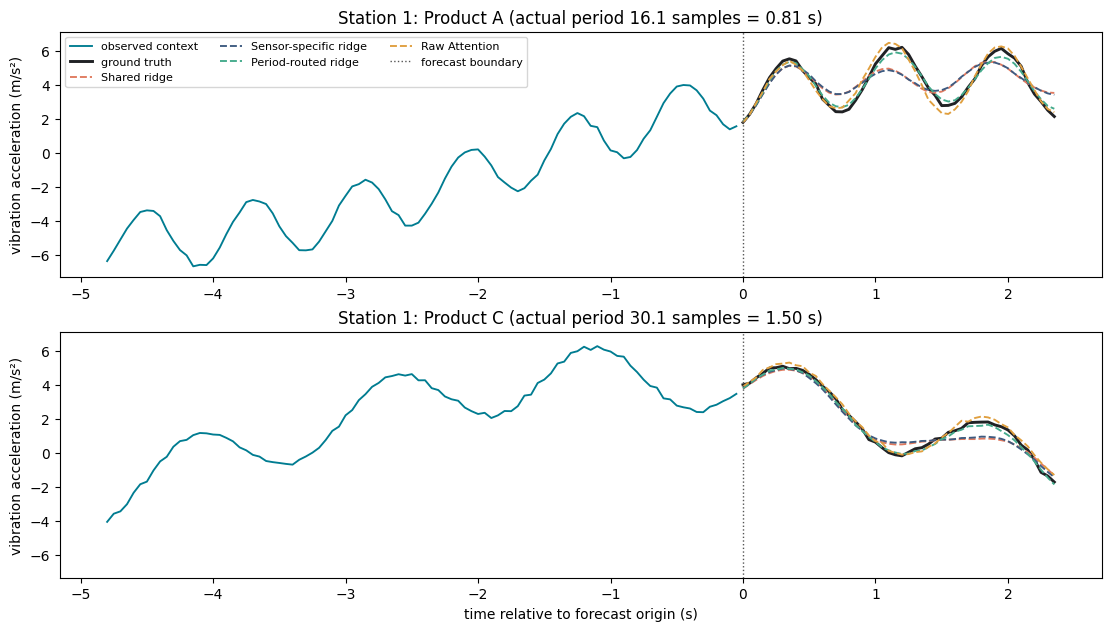

In [ ]:
report.publish("1.2", figures.regime_forecasts(
    study, ["Shared ridge", "Sensor-specific ridge", "Period-routed ridge", "Raw Attention"]))


Output 1.3


,station,product,actual period (samples),mean |Attention weight difference|,max |Attention weight difference|
0,1,Product A,16.135,unavailable,unavailable
1,1,Product C,30.093,unavailable,unavailable
2,1,Product A vs Product C (difference),unavailable,0.013,0.355


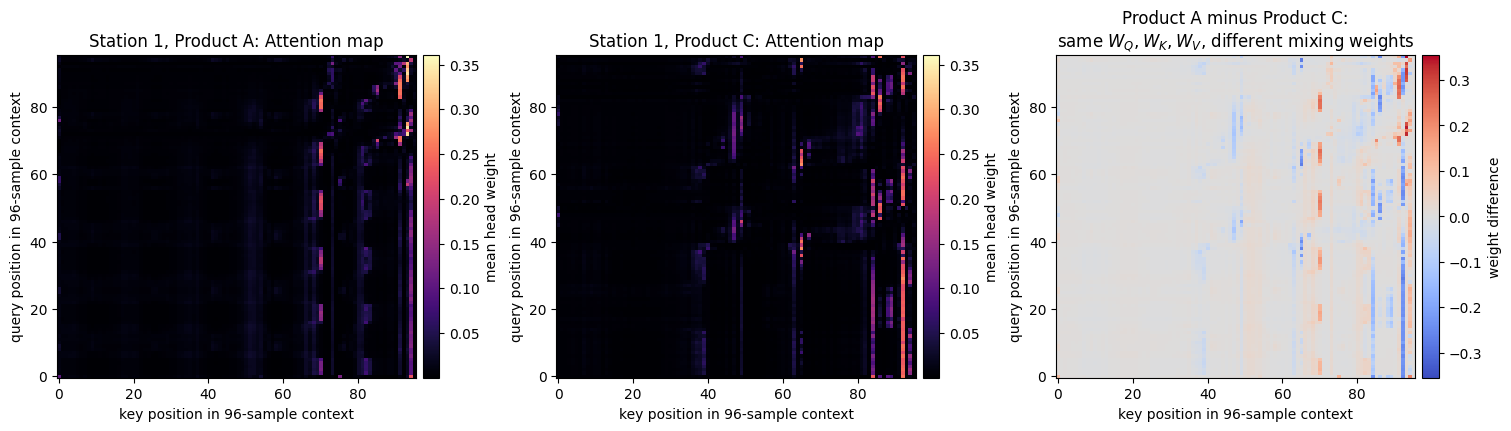

In [ ]:
report.publish("1.3", figures.attention_behaviour(study))


## 2. Separate Slow Structure from Repetition





In [ ]:
class SeriesDecomposition(nn.Module):
    def __init__(self, kernel):
        super().__init__()
        if kernel < 1 or kernel % 2 == 0:
            raise ValueError("kernel must be positive and odd")
        self.kernel = kernel

    def forward(self, x):                       # x [B,L,C] -> (remainder, trend), each [B,L,C]
        # trend[t] is the mean of x over the window [t - kernel//2, t + kernel//2].
        # Where that window runs off either end, repeat the nearest value in the sequence
        # rather than padding with zeros. Return x - trend as the remainder, so the two
        # streams reconstruct x exactly.
        pad = self.kernel // 2
        padded = torch.cat([x[:, :1].expand(-1, pad, -1), x,
                            x[:, -1:].expand(-1, pad, -1)], dim=1)
        trend = F.avg_pool1d(padded.transpose(1, 2), self.kernel, stride=1).transpose(1, 2)
        return x - trend, trend


In [ ]:
# Read this before running the check: kernel 3 on one short sequence, so the endpoint rule
# is visible. Interior: trend[1] = (1+2+3)/3 = 2. First position: the window needs x[-1], which
# is replicated from x[0], giving (1+1+2)/3 = 1.333 -- zero padding would give 1.0 instead.
example = torch.tensor([1., 2., 3., 10., 5.]).reshape(1, 5, 1)
remainder, trend = SeriesDecomposition(3)(example)
display(pd.DataFrame({
    "x": example.flatten(),
    "your trend": trend.flatten(),
    "expected trend": [4 / 3, 2., 5., 6., 20 / 3],
    "your remainder": remainder.flatten(),
}).round(4))


,x,your trend,expected trend,your remainder
0,1.0,1.3333,1.3333,-0.3333
1,2.0,2.0000,2.0000,0.0000
2,3.0,5.0000,5.0000,-2.0000
3,10.0,6.0000,6.0000,4.0000
4,5.0,6.6667,6.6667,-1.6667


Decomposition checks passed.
Decomposed-Attention assembly and gradient checks passed.
Output 2.1


,width,selected,residual std (m/s²),trend range (m/s²)
0,17,False,0.578,8.768
1,25,False,1.012,8.037
2,33,False,1.372,8.076
3,41,True,1.572,8.280


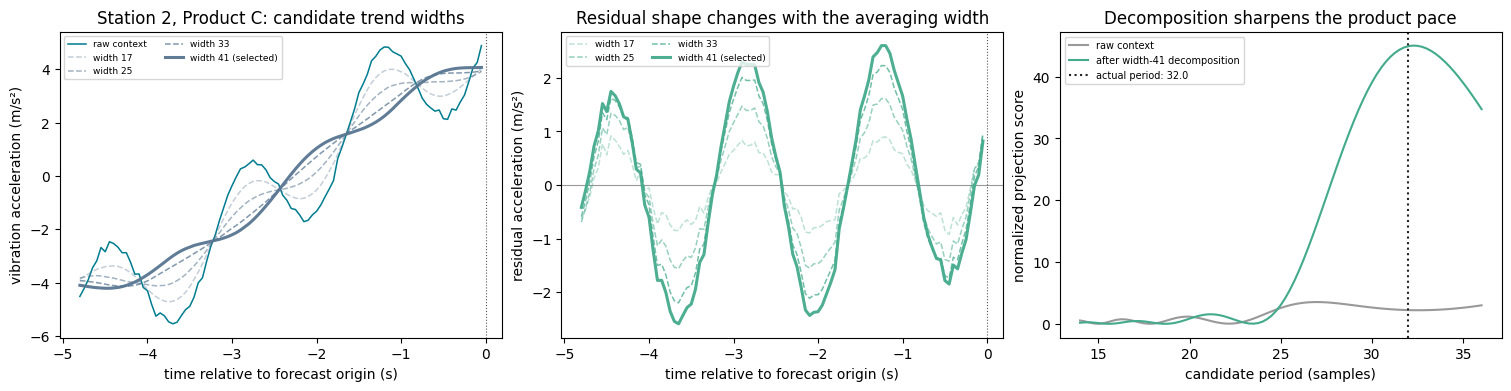

Output 2.2


,representation,oracle recovery within one sample,median absolute period error (samples),selected
0,raw,0.687,0.525,False
1,width 17,0.980,0.157,False
2,width 25,0.989,0.122,False
3,width 33,0.993,0.142,False
4,width 41,0.998,0.216,True


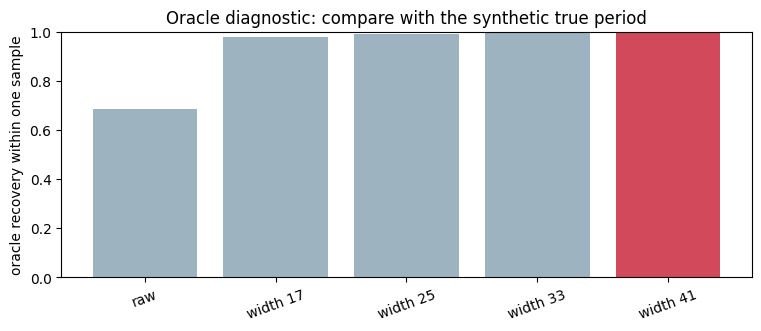

In [ ]:
assert design.check_decomposition(SeriesDecomposition)
design.register_components(decomposition_type=SeriesDecomposition)

# Supplied Part 2 model: Attention mixes the remainder; a linear head forecasts the trend.
class DecompositionAttentionBlock(nn.Module):
    def __init__(self, d, heads, kernel, decomposition_type, dropout):
        super().__init__()
        self.mix = DenseAttention(d, heads)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        self.strip1, self.strip2 = decomposition_type(kernel), decomposition_type(kernel)

    def forward(self, x):                       # [B,L,d]
        x, _ = self.strip1(x + self.drop(self.mix(self.norm1(x))))
        x, _ = self.strip2(x + self.drop(self.feed_forward(self.norm2(x))))
        return x                               # [B,L,d]

class DecomposedAttentionForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 kernel=25, dropout=0.1, decomposition_type=None):
        super().__init__()
        self.split = decomposition_type(kernel)
        self.trend_head = nn.Linear(context, horizon)
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([DecompositionAttentionBlock(
            d, heads, kernel, decomposition_type, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # [B,L,1] -> [B,H]
        seasonal, trend = self.split(context)
        encoded = self.embed(seasonal.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            encoded = block(encoded)
        seasonal_forecast = self.forecast_head(self.norm(encoded).flatten(1))
        return seasonal_forecast + self.trend_head(trend.squeeze(-1))

    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks]

assert design.check_decomposed_attention_assembly(DecomposedAttentionForecaster, SeriesDecomposition)
design.register_components(decomposed_attention_forecaster_type=DecomposedAttentionForecaster)
report.publish("2.1", figures.filter_decomposition(study))
report.publish("2.2", figures.recurrence_recovery(study))


Attention + decomposition: loaded attention-decomposition-full-data0-model0-020e48a7bbde.pt (6000 steps, 90.1s on cuda)
Output 2.3


,model,population,product,MSE,RMSE (m/s²),MAE (m/s²)
0,Raw Attention,established,Product A,0.177,0.421,0.314
1,Raw Attention,established,Product B,0.216,0.465,0.344
2,Raw Attention,established,Product C,0.172,0.414,0.311
3,Raw Attention,held-out,Product A,0.466,0.682,0.518
4,Raw Attention,held-out,Product B,0.376,0.613,0.453
5,Raw Attention,held-out,Product C,0.489,0.699,0.522
6,Attention + decomposition,established,Product A,0.087,0.295,0.225
7,Attention + decomposition,established,Product B,0.127,0.356,0.259
8,Attention + decomposition,established,Product C,0.075,0.275,0.203
9,Attention + decomposition,held-out,Product A,0.162,0.402,0.306


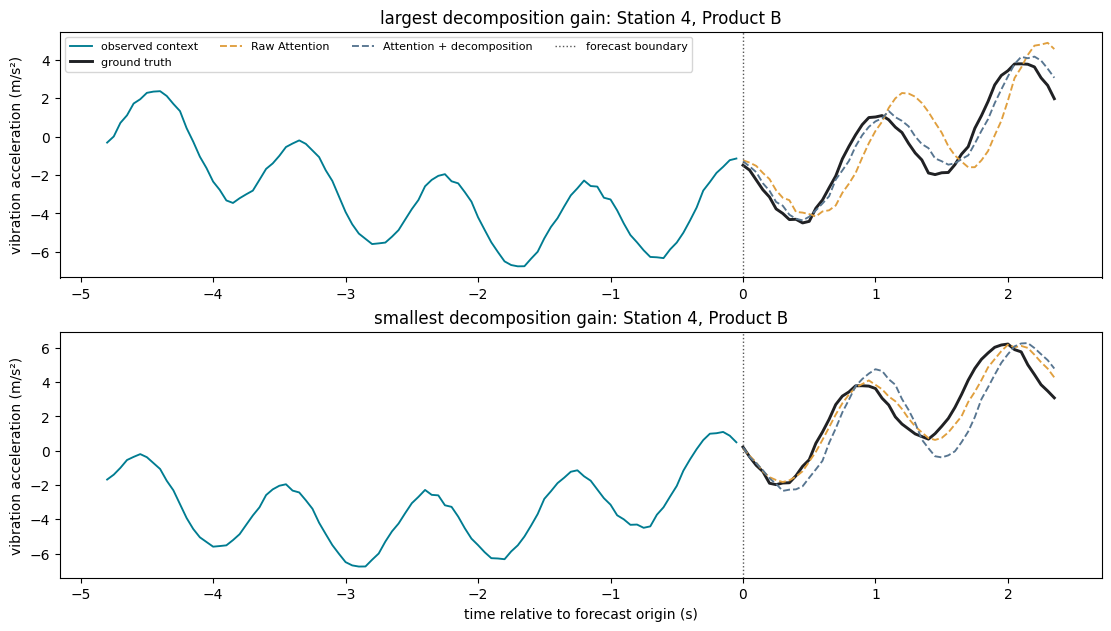

In [ ]:
study.train("Attention + decomposition")
report.publish("2.3", figures.decomposition_ablation(study))


## 3. Mix by Temporal Delay

Switch 2 replaces the mixer rather than changing what the mixer is shown. Delay mixing scores
every delay, keeps the best few from the fixed band, sharpens them with a learned temperature,
and combines shifted copies of the context. Scoring every delay (`delay_scores`) is supplied;
you write the aggregation (`aggregate_delays`) that turns scored delays into a mixed sequence.

The mental model is: **score delays → select useful delays → shift values → combine them.**

Produces **Outputs 3.1–3.2** → used in **Response 3**.


### Delay scores (supplied)

`delay_scores(queries, keys)` takes tensors of shape `(batch, heads, features, time)` and returns
one score per delay, of shape `(batch, time)`. It is supplied below: it computes every delay's
score with two real forward FFTs and one inverse real FFT, in `O(L log L)` rather than the
`O(L^2)` a loop over delays would cost. You do not need to derive or reconstruct this procedure.

| Cell below | Output | Read it for |
| --- | --- | --- |
| the supplied scores on `[1, 3, 1, 3]`, against a direct calculation | 3.1 | Response 3 |


In [ ]:
def delay_scores(queries, keys):
    # queries, keys: [B,heads,features,L] -> scores [B,L], one per delay tau = 0 .. L-1.
    # R(tau) = sum_t q[t] * k[(t - tau) mod L], centered in time, averaged over heads and
    # features. Supplied: an FFT computes every delay's score together in O(L log L).
    queries = queries - queries.mean(-1, keepdim=True)
    keys = keys - keys.mean(-1, keepdim=True)
    spectrum = torch.fft.rfft(queries, dim=-1) * torch.fft.rfft(keys, dim=-1).conj()
    return torch.fft.irfft(spectrum, n=queries.shape[-1], dim=-1).mean((1, 2))


In [ ]:
# delay_scores is supplied above. This toy example confirms it against a direct circular
# correlation for q = k = [1, 3, 1, 3], which centers to [-1, 1, -1, 1].
example = torch.tensor([1., 3., 1., 3.]).reshape(1, 1, 1, 4)
scores = pd.DataFrame({"delay": range(4),
                       "delay_scores (FFT)": delay_scores(example, example).flatten().tolist(),
                       "direct circular correlation": [4., -4., 4., -4.]})
display(scores.round(6))

assert design.check_delay_scores(delay_scores)
design.register_components(delay_scores=delay_scores)
report.publish("3.1", scores)


,delay,delay_scores (FFT),direct circular correlation
0,0,4.0,4.0
1,1,-4.0,-4.0
2,2,4.0,4.0
3,3,-4.0,-4.0


FFT delay-score checks passed.
Output 3.1


,delay,delay_scores (FFT),direct circular correlation
0,0,4.0,4.0
1,1,-4.0,-4.0
2,2,4.0,4.0
3,3,-4.0,-4.0


### Delay aggregation




In [ ]:
def aggregate_delays(values, delays, weights):
    # values: [B,heads,features,L]; delays, weights: [B,K] -> [B,heads,features,L]
    # z[t] = sum_j weights[j] * values[(t - delays[j]) mod L], per example, shared across
    # that example's heads and features. Keep it differentiable in both values and weights.
    length = values.shape[-1]
    time = torch.arange(length, device=values.device)
    mixed = torch.zeros_like(values)
    for j in range(delays.shape[1]):
        index = (time - delays[:, j:j + 1]) % length    # [B,L]
        index = index[:, None, None, :].expand_as(values)
        mixed = mixed + weights[:, j, None, None, None] * values.gather(-1, index)
    return mixed


In [ ]:
# Let v = [10, 20, 30, 40], delays [1, 3], and weights [3/4, 1/4].
# z0 = 3/4 * v[3] + 1/4 * v[1] = 30 + 5 = 35. If you get 25, the shift runs the wrong way.
values = torch.tensor([10., 20., 30., 40.]).reshape(1, 1, 1, 4)
mixed = aggregate_delays(values, torch.tensor([[1, 3]]), torch.tensor([[.75, .25]]))
aggregated = pd.DataFrame({"position": range(4),
                           "your aggregated value": mixed.flatten(),
                           "expected": [35., 15., 25., 25.]})
display(aggregated.round(6))

assert design.check_aggregation(aggregate_delays)
design.register_components(aggregate=aggregate_delays)


,position,your aggregated value,expected
0,0,35.0,35.0
1,1,15.0,15.0
2,2,25.0,25.0
3,3,25.0,25.0


Delay-aggregation checks passed.


### Delay mixer (supplied)



In [ ]:
class DelayMixer(nn.Module):
    def __init__(self, d, heads, delay_score_fn, aggregate_fn, min_delay=8, max_delay=48):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads, self.min_delay, self.max_delay = heads, min_delay, max_delay
        self.delay_score_fn, self.aggregate_fn = delay_score_fn, aggregate_fn
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.raw_temperature = nn.Parameter(torch.tensor(0.5413248546))

    @property
    def temperature(self):
        return F.softplus(self.raw_temperature) + 1e-6

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).permute(0, 2, 3, 1)
                   for layer in (self.query, self.key, self.value))  # [B,h,d_h,L]
        scores = self.delay_score_fn(q, k)      # [B,L]
        lo, hi = self.min_delay, min(self.max_delay, length - 1)
        band = scores[:, lo:hi + 1]
        top_k = min(math.ceil(2 * math.log(length)), band.shape[-1])
        selected, indices = band.topk(top_k, dim=-1)
        delays = indices + lo                  # [B,K]
        weights = (selected / self.temperature).softmax(-1)  # [B,K]
        mixed = self.aggregate_fn(v, delays, weights)         # [B,h,d_h,L]
        return self.out(mixed.permute(0, 3, 1, 2).reshape(batch, length, width))


### Output 3.2 — Signal-level recurrence diagnostic



Output 3.2


,station,product,expected delay (samples),nearest integer delay,residual signal correlation
0,2,Product A,16.135,16,0.896
1,2,Product A,32.269,32,0.897


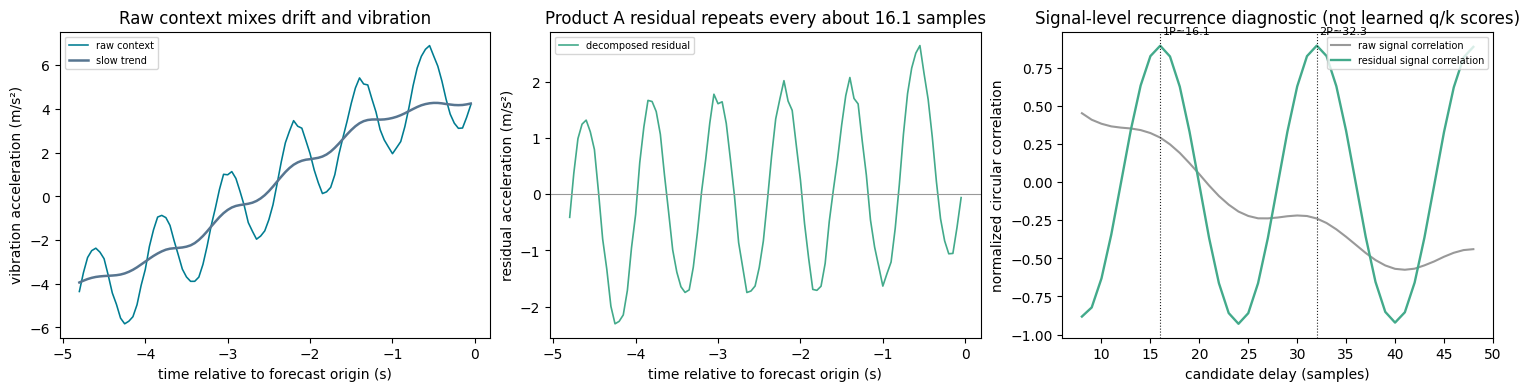

In [ ]:
recurrence = figures.delay_recurrence(study)
report.publish("3.2", recurrence)


## 4. Compare Designs and Deploy



### Prediction for Response 4(a)


Model assembly and gradient checks passed (4 setting(s): raw/attention, raw/delay, decomposed/attention, decomposed/delay).
Raw delay mixer: loaded raw-delay-mixer-full-data0-model0-4864d9a7efa3.pt (6000 steps, 104.6s on cuda)
Autoformer-inspired: loaded autoformer-inspired-full-data0-model0-c5f6a128647a.pt (6000 steps, 122.5s on cuda)
Output 4.1


,model,established stations RMSE (m/s²),established stations MSE (m/s²)²,"established stations, Product A RMSE","established stations, Product B RMSE","established stations, Product C RMSE",held-out station 4 RMSE (m/s²),held-out station 4 MSE (m/s²)²,"held-out station 4, Product A RMSE","held-out station 4, Product B RMSE","held-out station 4, Product C RMSE",parameters,fit seconds
0,Raw Attention,0.434,0.188,0.421,0.465,0.414,0.666,0.443,0.682,0.613,0.699,368368,74.951
1,Raw delay mixer,0.229,0.053,0.210,0.215,0.260,0.329,0.108,0.389,0.281,0.308,368370,104.555
2,Attention + decomposition,0.311,0.096,0.295,0.356,0.275,0.465,0.216,0.402,0.544,0.436,373024,90.114
3,Autoformer-inspired,0.197,0.039,0.223,0.181,0.184,0.242,0.058,0.275,0.216,0.230,373026,122.475


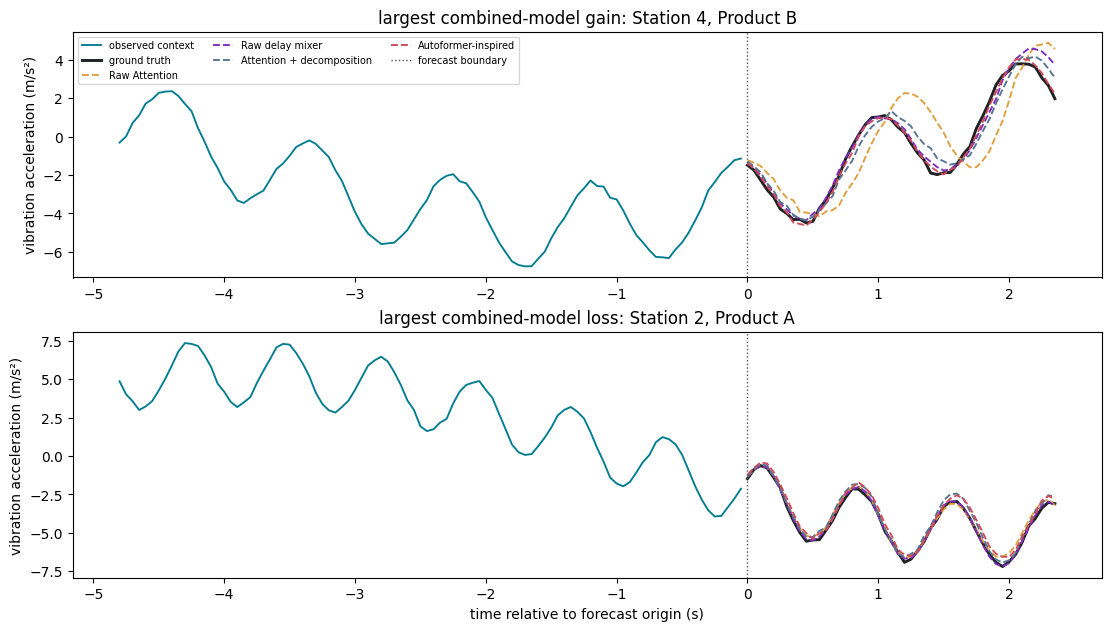

,case,station,product,model,window RMSE (m/s²)
0,largest combined-model gain,4,Product B,Raw Attention,1.644
1,largest combined-model gain,4,Product B,Raw delay mixer,0.499
2,largest combined-model gain,4,Product B,Attention + decomposition,0.581
3,largest combined-model gain,4,Product B,Autoformer-inspired,0.184
4,largest combined-model loss,2,Product A,Raw Attention,0.274
5,largest combined-model loss,2,Product A,Raw delay mixer,0.115
6,largest combined-model loss,2,Product A,Attention + decomposition,0.326
7,largest combined-model loss,2,Product A,Autoformer-inspired,0.384


In [ ]:
# Supplied unified 2×2 design.
class IdentitySplit(nn.Module):
    def forward(self, x):
        return x, torch.zeros_like(x)

class EncoderBlock(nn.Module):
    def __init__(self, d, heads, mixing, kernel, decomposition_type,
                 delay_score_fn, aggregate_fn, dropout):
        super().__init__()
        self.mix = (DelayMixer(d, heads, delay_score_fn, aggregate_fn)
                    if mixing == "delay" else DenseAttention(d, heads))
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        split = decomposition_type if decomposition_type is not None else lambda _: IdentitySplit()
        self.strip1, self.strip2 = split(kernel), split(kernel)

    def forward(self, x):                       # [B,L,d]
        x, _ = self.strip1(x + self.drop(self.mix(self.norm1(x))))
        x, _ = self.strip2(x + self.drop(self.feed_forward(self.norm2(x))))
        return x                               # [B,L,d]

class AutoformerInspiredForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 mixing="attention", representation="raw", kernel=25, dropout=0.1,
                 decomposition_type=None, delay_score_fn=None, aggregate_fn=None):
        super().__init__()
        if representation not in {"raw", "decomposed"}:
            raise ValueError("representation must be 'raw' or 'decomposed'")
        self.split = (decomposition_type(kernel) if representation == "decomposed"
                      else IdentitySplit())
        self.trend_head = nn.Linear(context, horizon) if representation == "decomposed" else None
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([EncoderBlock(
            d, heads, mixing, kernel, decomposition_type, delay_score_fn, aggregate_fn, dropout)
            for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # [B,L,1] -> [B,H]
        seasonal, trend = self.split(context)
        encoded = self.embed(seasonal.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            encoded = block(encoded)
        seasonal_forecast = self.forecast_head(self.norm(encoded).flatten(1))
        trend_forecast = 0 if self.trend_head is None else self.trend_head(trend.squeeze(-1))
        return seasonal_forecast + trend_forecast

    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DenseAttention)]

    @property
    def delay_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DelayMixer)]

assert design.check_assembly(AutoformerInspiredForecaster)
design.register_components(forecaster_type=AutoformerInspiredForecaster)
study.train("Raw delay mixer")
study.train("Autoformer-inspired")
cases = figures.contrasting_forecasts(study)
report.publish("4.1", report.comparison(study, [
    "Raw Attention", "Raw delay mixer", "Attention + decomposition", "Autoformer-inspired"]))
display(cases.round(3))


Output 4.2


,model,population,horizon,MSE,RMSE (m/s²)
0,Period-routed ridge,established,1,0.013,0.112
1,Period-routed ridge,established,2,0.011,0.107
2,Period-routed ridge,established,3,0.014,0.118
3,Period-routed ridge,established,4,0.014,0.118
4,Period-routed ridge,established,5,0.015,0.121
...,...,...,...,...,...
475,Autoformer-inspired,held-out,44,0.103,0.320
476,Autoformer-inspired,held-out,45,0.113,0.336
477,Autoformer-inspired,held-out,46,0.107,0.327
478,Autoformer-inspired,held-out,47,0.112,0.335


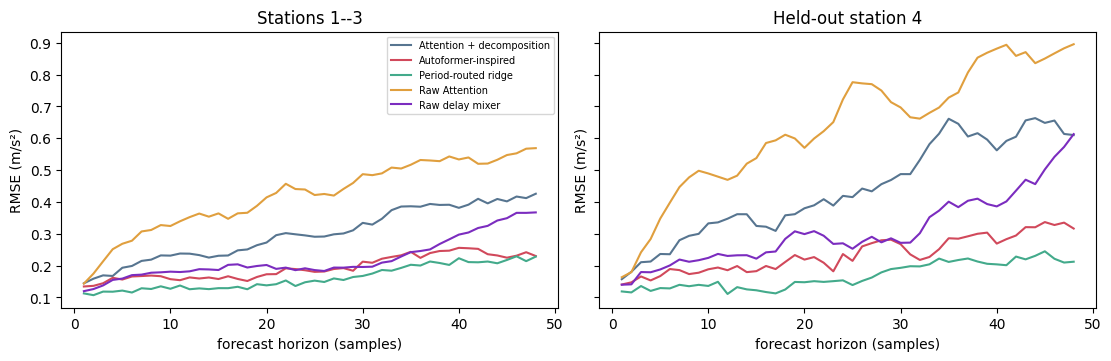

In [ ]:
report.publish("4.2", figures.horizon_figure(study, [
    "Period-routed ridge", "Raw Attention", "Raw delay mixer",
    "Attention + decomposition", "Autoformer-inspired"]))


### Choose the deployment models (Response 4)



In [ ]:
# Validation-only decision summary.
display(report.deployment_summary(study).round(3))


,model,established validation RMSE (m/s²),established validation MSE (m/s²)²,held-out validation RMSE (m/s²),held-out validation MSE (m/s²)²,parameters,fit seconds
0,Shared ridge,0.767,0.588,0.876,0.767,4608,0.031
1,Sensor-specific ridge,0.768,0.590,NaN,NaN,13824,0.144
2,Period-routed ridge,0.166,0.028,0.173,0.030,59904,0.030
3,Raw Attention,0.434,0.188,0.666,0.443,368368,74.951
4,Attention + decomposition,0.311,0.096,0.465,0.216,373024,90.114
5,Raw delay mixer,0.229,0.053,0.329,0.108,368370,104.555
6,Autoformer-inspired,0.197,0.039,0.242,0.058,373026,122.475


In [ ]:
# Cheapest fitted model within 5% of the best validation RMSE, per population (validation only).
summary = report.deployment_summary(study)
def cheapest_within(column, tolerance=1.05):
    pool = summary[summary[column] <= tolerance * summary[column].min()]
    return pool.sort_values(["parameters", "fit seconds"]).iloc[0]["model"]

choices = {
    "established": cheapest_within("established validation RMSE (m/s²)"),
    "held-out": cheapest_within("held-out validation RMSE (m/s²)"),
}
display(study.select_for_test(choices))

,population,model
0,established,Period-routed ridge
1,held-out,Period-routed ridge


In [ ]:
report.publish("4.3", study.selected_test_table())


Output 4.3


,population,model,validation MSE,validation RMSE (m/s²),test MSE,test RMSE (m/s²)
0,established,Period-routed ridge,0.028,0.166,0.026,0.161
1,held-out,Period-routed ridge,0.030,0.173,0.033,0.183


## Supplementary analyses (validation only)




In [ ]:
# S1. Errors by the size of the slow drift in each context (established stations, validation).
# slow_change is the true range of the slow component, so this is an oracle diagnostic only.
part = study.region("validation")
keep = study.mask("established", "validation")
drift = part["slow_change"][keep]
group = np.digitize(drift, np.quantile(drift, [1 / 3, 2 / 3]))
target = part["target"][keep]
predictions = study.predictions("validation")
order = ["Period-routed ridge", "Raw Attention", "Attention + decomposition",
         "Raw delay mixer", "Autoformer-inspired"]
rmse_by_drift = pd.DataFrame(
    {name: [float(np.sqrt(np.mean((predictions[name][keep][group == g] - target[group == g]) ** 2)))
            for g in range(3)] for name in order},
    index=[f"drift tercile {g + 1} (range {drift[group == g].min():.1f} to {drift[group == g].max():.1f} m/s²)"
           for g in range(3)]).T
rmse_by_drift["change over low to high"] = rmse_by_drift.iloc[:, 2] - rmse_by_drift.iloc[:, 0]
effects = pd.DataFrame({
    "decomposition added to Attention": rmse_by_drift.loc["Attention + decomposition"] - rmse_by_drift.loc["Raw Attention"],
    "decomposition added to delay mixer": rmse_by_drift.loc["Autoformer-inspired"] - rmse_by_drift.loc["Raw delay mixer"],
    "delay mixer replaces Attention (raw)": rmse_by_drift.loc["Raw delay mixer"] - rmse_by_drift.loc["Raw Attention"],
    "delay mixer replaces Attention (decomposed)": rmse_by_drift.loc["Autoformer-inspired"] - rmse_by_drift.loc["Attention + decomposition"],
}).T
display(rmse_by_drift.round(3))
print("RMSE change from switching on each upgrade (negative means the upgrade helps)")
display(effects.round(3))


,drift tercile 1 (range 3.3 to 5.7 m/s²),drift tercile 2 (range 5.8 to 7.9 m/s²),drift tercile 3 (range 8.1 to 9.9 m/s²),change over low to high
Period-routed ridge,0.168,0.167,0.163,-0.005
Raw Attention,0.490,0.440,0.362,-0.128
Attention + decomposition,0.303,0.310,0.318,0.016
Raw delay mixer,0.219,0.265,0.199,-0.020
Autoformer-inspired,0.202,0.188,0.200,-0.002


RMSE change from switching on each upgrade (negative means the upgrade helps)


,drift tercile 1 (range 3.3 to 5.7 m/s²),drift tercile 2 (range 5.8 to 7.9 m/s²),drift tercile 3 (range 8.1 to 9.9 m/s²),change over low to high
decomposition added to Attention,-0.187,-0.130,-0.044,0.143
decomposition added to delay mixer,-0.017,-0.077,0.001,0.018
delay mixer replaces Attention (raw),-0.271,-0.175,-0.163,0.107
delay mixer replaces Attention (decomposed),-0.101,-0.122,-0.118,-0.018


In [ ]:
# S2. Paired bootstrap over operating runs (validation). Windows in one 192-sample run share a pace,
# so whole runs are resampled. The model seed is fixed here, so this ignores training variance (see S3).
part = study.region("validation")
runs_index = part["regime"]
run_ids = np.unique(runs_index)
rng = np.random.default_rng(0)
draws = rng.integers(0, len(run_ids), (2000, len(run_ids)))

def squared_error_by_run(name, population):
    keep = study.mask(population, "validation")
    error = (predictions[name] - part["target"]) ** 2
    selected = [keep & (runs_index[None, :] == r) for r in run_ids]
    return (np.array([error[s].sum() for s in selected]),
            np.array([s.sum() * data.HORIZON for s in selected]))

def rmse_difference(a, b, population):
    (ta, n), (tb, _) = squared_error_by_run(a, population), squared_error_by_run(b, population)
    point = np.sqrt(ta.sum() / n.sum()) - np.sqrt(tb.sum() / n.sum())
    diff = np.sqrt(ta[draws].sum(1) / n[draws].sum(1)) - np.sqrt(tb[draws].sum(1) / n[draws].sum(1))
    return dict(comparison=f"{a} minus {b}", population=population, RMSE_difference=point,
                ci_low=np.percentile(diff, 2.5), ci_high=np.percentile(diff, 97.5),
                runs_a_better=int(((ta / n) < (tb / n)).sum()), runs=len(run_ids))

pairs = [("Attention + decomposition", "Raw Attention"), ("Raw delay mixer", "Raw Attention"),
         ("Autoformer-inspired", "Raw delay mixer"), ("Autoformer-inspired", "Attention + decomposition"),
         ("Autoformer-inspired", "Period-routed ridge"), ("Period-routed ridge", "Raw Attention")]
display(pd.DataFrame([rmse_difference(a, b, p) for p in ("established", "held-out")
                      for a, b in pairs]).round(3))


,comparison,population,RMSE_difference,ci_low,ci_high,runs_a_better,runs
0,Attention + decomposition minus Raw Attention,established,-0.123,-0.147,-0.102,15,15
1,Raw delay mixer minus Raw Attention,established,-0.205,-0.245,-0.163,15,15
2,Autoformer-inspired minus Raw delay mixer,established,-0.033,-0.085,0.007,9,15
3,Autoformer-inspired minus Attention + decompos...,established,-0.114,-0.149,-0.081,15,15
4,Autoformer-inspired minus Period-routed ridge,established,0.031,0.013,0.048,2,15
5,Period-routed ridge minus Raw Attention,established,-0.268,-0.314,-0.222,15,15
6,Attention + decomposition minus Raw Attention,held-out,-0.201,-0.272,-0.132,12,15
7,Raw delay mixer minus Raw Attention,held-out,-0.337,-0.398,-0.274,15,15
8,Autoformer-inspired minus Raw delay mixer,held-out,-0.087,-0.136,-0.042,12,15
9,Autoformer-inspired minus Attention + decompos...,held-out,-0.223,-0.300,-0.153,15,15


In [ ]:
# S3. Three model seeds on the same data. Seed 0 is the study above; seeds 1 and 2 are fitted here.
# Cost on a Colab GPU: about 7 minutes per extra seed. Set PA1_SEEDS=0 to skip the extra fits.
seeds = [int(s) for s in os.environ.get("PA1_SEEDS", "0,1,2").split(",")]
neural = ["Raw Attention", "Attention + decomposition", "Raw delay mixer", "Autoformer-inspired"]
seed_rows = []
for k in seeds:
    run = study if k == model_seed else design.Study(preset, seed, model_seed=k)
    for name in neural:
        run.train(name)
    table = run.model_table("validation")
    for name in neural:
        for population in ("established", "held-out"):
            row = table[(table.model == name) & (table.population == population)].iloc[0]
            seed_rows.append(dict(model=name, population=population, seed=k, RMSE=row["RMSE (m/s²)"]))
seed_table = pd.DataFrame(seed_rows)
summary = (seed_table.groupby(["population", "model"], sort=False).RMSE.agg(["mean", "std", "min", "max"])
           .reset_index())
summary["seeds"] = len(seeds)
display(summary.round(3))
wide = seed_table.pivot_table(index=["population", "seed"], columns="model", values="RMSE")
for population, block in wide.groupby(level="population"):
    helped = block.drop(columns="Raw Attention").lt(block["Raw Attention"], axis=0).all(axis=1).sum()
    print(f"{population}: Autoformer-inspired beats Raw delay mixer in "
          f"{int((block['Autoformer-inspired'] < block['Raw delay mixer']).sum())} of {len(block)} seeds, "
          f"and every other model beats Raw Attention in {int(helped)} of {len(block)} seeds")


Raw Attention: 6000 steps, 75.5s, 368368 parameters, best established-validation MSE 0.230 (m/s²)² -- same physical units as the report tables below
Raw Attention: saved raw-attention-full-data0-model1-718a855924b5.pt
Attention + decomposition: 6000 steps, 93.1s, 373024 parameters, best established-validation MSE 0.079 (m/s²)² -- same physical units as the report tables below
Attention + decomposition: saved attention-decomposition-full-data0-model1-5c582120edc3.pt
Raw delay mixer: 6000 steps, 109.5s, 368370 parameters, best established-validation MSE 0.045 (m/s²)² -- same physical units as the report tables below
Raw delay mixer: saved raw-delay-mixer-full-data0-model1-802ee82f421f.pt
Autoformer-inspired: 6000 steps, 127.9s, 373026 parameters, best established-validation MSE 0.031 (m/s²)² -- same physical units as the report tables below
Autoformer-inspired: saved autoformer-inspired-full-data0-model1-e92e40d2f93b.pt
Raw Attention: 6000 steps, 72.4s, 368368 parameters, best establishe

,population,model,mean,std,min,max,seeds
0,established,Raw Attention,0.445,0.031,0.421,0.479,3
1,held-out,Raw Attention,0.690,0.070,0.636,0.769,3
2,established,Attention + decomposition,0.289,0.019,0.274,0.311,3
3,held-out,Attention + decomposition,0.433,0.028,0.413,0.465,3
4,established,Raw delay mixer,0.211,0.019,0.191,0.229,3
5,held-out,Raw delay mixer,0.311,0.025,0.282,0.329,3
6,established,Autoformer-inspired,0.189,0.012,0.176,0.197,3
7,held-out,Autoformer-inspired,0.238,0.022,0.215,0.258,3


established: Autoformer-inspired beats Raw delay mixer in 2 of 3 seeds, and every other model beats Raw Attention in 3 of 3 seeds
held-out: Autoformer-inspired beats Raw delay mixer in 3 of 3 seeds, and every other model beats Raw Attention in 3 of 3 seeds


In [ ]:
# S4. Recurrence at the true period, averaged over all validation windows (established stations).
# Output 3.2 shows one chosen window; this averages the same circular autocorrelation over all windows.
part = study.region("validation")
keep = study.mask("established", "validation")
context = part["context"][keep]
period = part["primary_period"][keep]
product = np.broadcast_to(part["product"][None, :], keep.shape)[keep]
residual = context - data.moving_average(context, study.decomposition_kernel)

def circular_correlation(signal, lag):
    centred = signal - signal.mean(-1, keepdims=True)
    return (centred * np.array([np.roll(row, int(l)) for row, l in zip(centred, lag)])).sum(-1) / (centred ** 2).sum(-1)

rows = []
for multiple in (1, 2):
    lag = np.rint(multiple * period).astype(int)
    usable = lag <= 48
    for index, name in enumerate(study.world.product_names):
        pick = usable & (product == index)
        if pick.sum():
            rows.append({"product": name, "lag": f"{multiple} x period", "windows": int(pick.sum()),
                         "raw signal correlation (mean)": float(circular_correlation(context[pick], lag[pick]).mean()),
                         "residual signal correlation (mean)": float(circular_correlation(residual[pick], lag[pick]).mean())})
display(pd.DataFrame(rows).round(3))


,product,lag,windows,raw signal correlation (mean),residual signal correlation (mean)
0,Product A,1 x period,105,0.414,0.687
1,Product B,1 x period,105,0.168,0.721
2,Product C,1 x period,105,-0.018,0.736
3,Product A,2 x period,105,-0.095,0.469
4,Product B,2 x period,63,-0.236,0.600


In [ ]:
# Zip the outputs and checkpoints; on Colab the zip downloads automatically.
with zipfile.ZipFile("task1_results.zip", "w") as archive:
    for path in [*Path("results").rglob("*"), *Path("checkpoints").rglob("*")]:
        archive.write(path)
try:
    from google.colab import files
    files.download("task1_results.zip")
except ImportError:
    print("Saved", Path("task1_results.zip").resolve())


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>